# SMS Spam Detection

This notebook demonstrates SMS spam detection using machine learning.

In [15]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pickle

## Load Data

In [16]:
# Load the dataset
df = pd.read_csv('../data/SMSSpamCollection', sep='\t', names=['label', 'message'])
print(df.head())
print(f"Dataset shape: {df.shape}")
df.isnull().sum()
df.duplicated().sum()
print(df.isnull().sum())
print(df.isnull().sum())
df = df.drop_duplicates()
print("New Shape:", df.shape)
print("Remaining Duplicates:", df.duplicated().sum())

  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...
Dataset shape: (5572, 2)
label      0
message    0
dtype: int64
label      0
message    0
dtype: int64
New Shape: (5169, 2)
Remaining Duplicates: 0


## Exploratory Data Analysis

In [17]:
# Check class distribution
print(df['label'].value_counts())
print(f"\nClass distribution:\n{df['label'].value_counts(normalize=True)}")

label
ham     4516
spam     653
Name: count, dtype: int64

Class distribution:
label
ham     0.87367
spam    0.12633
Name: proportion, dtype: float64


In [18]:
# Check class distribution
print(df['label'].value_counts())
print(f"\nClass distribution:\n{df['label'].value_counts(normalize=True)}")

label
ham     4516
spam     653
Name: count, dtype: int64

Class distribution:
label
ham     0.87367
spam    0.12633
Name: proportion, dtype: float64


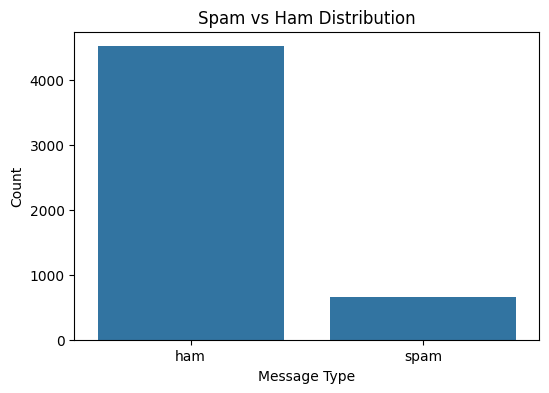

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x='label', data=df)

plt.title('Spam vs Ham Distribution')
plt.xlabel('Message Type')
plt.ylabel('Count')

plt.show()

In [20]:
df['message_length'] = df['message'].apply(len)

df[['message', 'message_length']].head()

,message,message_length
0,"Go until jurong point, crazy.. Available only ...",111
1,Ok lar... Joking wif u oni...,29
2,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,U dun say so early hor... U c already then say...,49
4,"Nah I don't think he goes to usf, he lives aro...",61


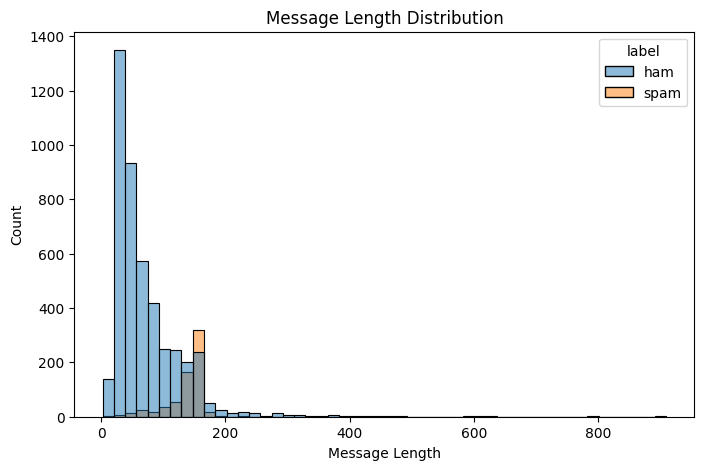

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(data=df, x='message_length', hue='label', bins=50)

plt.title('Message Length Distribution')
plt.xlabel('Message Length')
plt.ylabel('Count')

plt.show()

In [22]:
df.groupby('label')['message_length'].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
ham,4516.0,70.905890,56.715046,2.0,34.0,53.0,91.0,910.0
spam,653.0,137.704441,29.821348,13.0,132.0,148.0,157.0,223.0


## Boxplot Visualization

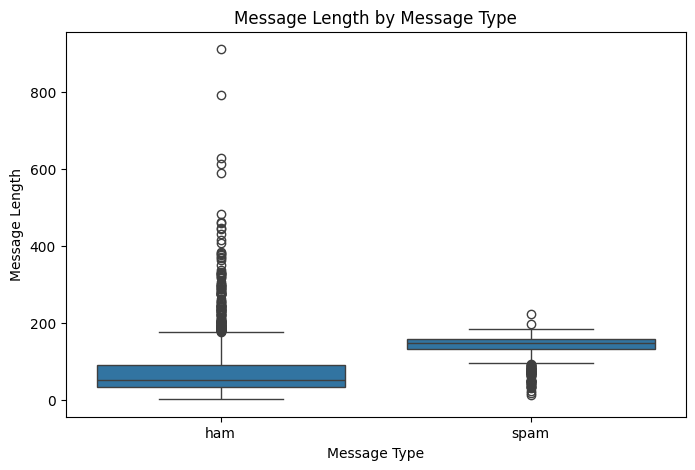

In [23]:
plt.figure(figsize=(8,5))

sns.boxplot(x='label', y='message_length', data=df)

plt.title('Message Length by Message Type')
plt.xlabel('Message Type')
plt.ylabel('Message Length')

plt.show()

## Start NLP Preprocessing

In [29]:
import nltk
import string
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

nltk.download('stopwords')

[nltk_data] Error loading stopwords: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1028)>


False

In [31]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from nltk.stem import PorterStemmer
import string

ps = PorterStemmer()

def transform_text(text):
    
    # Convert to lowercase
    text = text.lower()

    # Remove punctuation
    text = ''.join(char for char in text if char not in string.punctuation)

    # Tokenize
    words = text.split()

    # Remove stopwords
    words = [word for word in words if word not in ENGLISH_STOP_WORDS]

    # Apply stemming
    words = [ps.stem(word) for word in words]

    # Join words back into a sentence
    return " ".join(words)

In [32]:
transform_text("Congratulations! You have won a FREE prize. Click here now!!!")

'congratul won free prize click'

In [33]:
df['transformed_text'] = df['message'].apply(transform_text)

In [35]:
df[['message', 'transformed_text']].head()

,message,transformed_text
0,"Go until jurong point, crazy.. Available only ...",jurong point crazi avail bugi n great world la...
1,Ok lar... Joking wif u oni...,ok lar joke wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entri 2 wkli comp win fa cup final tkt 21...
3,U dun say so early hor... U c already then say...,u dun say earli hor u c say
4,"Nah I don't think he goes to usf, he lives aro...",nah dont think goe usf live


## TF-IDF

In [36]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=3000)

X = tfidf.fit_transform(df['transformed_text']).toarray()

X.shape

(5169, 3000)

In [37]:
y = df['label']

print(y.head())

0    0
1    0
2    1
3    0
4    0
Name: label, dtype: int64


In [39]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

y = encoder.fit_transform(df['label'])

print(encoder.classes_)
print(y[:5])

[0 1]
[0 0 1 0 0]


In [40]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (4135, 3000)
X_test: (1034, 3000)
y_train: (4135,)
y_test: (1034,)


In [41]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


In [43]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9806576402321083

Confusion Matrix:
[[893   1]
 [ 19 121]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       894
           1       0.99      0.86      0.92       140

    accuracy                           0.98      1034
   macro avg       0.99      0.93      0.96      1034
weighted avg       0.98      0.98      0.98      1034



/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


In [45]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9806576402321083

Confusion Matrix:
[[893   1]
 [ 19 121]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       894
           1       0.99      0.86      0.92       140

    accuracy                           0.98      1034
   macro avg       0.99      0.93      0.96      1034
weighted avg       0.98      0.98      0.98      1034



/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


## Save the Model

In [46]:
import pickle

pickle.dump(tfidf, open('../models/vectorizer.pkl', 'wb'))
pickle.dump(model, open('../models/spam_model.pkl', 'wb'))

print("Model and vectorizer saved successfully!")

Model and vectorizer saved successfully!


## Data Preprocessing & Model Training

In [25]:
# Convert labels to binary
df['label'] = df['label'].map({'ham': 0, 'spam': 1})

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    df['message'], df['label'], test_size=0.2, random_state=42
)

# Vectorize text
vectorizer = TfidfVectorizer(max_features=3000)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# Train model
model = MultinomialNB()
model.fit(X_train_vec, y_train)

print("Model trained successfully!")

Model trained successfully!


## Model Evaluation

In [26]:
# Make predictions
y_pred = model.predict(X_test_vec)

# Evaluate
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_pred):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred):.4f}")

Accuracy: 0.9778
Precision: 1.0000
Recall: 0.8357
F1-Score: 0.9105


## Save Model

In [27]:
# Save model and vectorizer
with open('../models/spam_model.pkl', 'wb') as f:
    pickle.dump(model, f)

with open('../models/vectorizer.pkl', 'wb') as f:
    pickle.dump(vectorizer, f)

print("Model and vectorizer saved!")

Model and vectorizer saved!
